<a href="https://colab.research.google.com/github/JaviHorse/Breast-Cancer-Predictor/blob/main/Breast_Cancer_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

Load the Dataset

In [ ]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv("sample_data/wdbc.data", header=None, names=columns)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Basic Dataset Summary

In [ ]:
print("Dataset shape:", df.shape)
print("\nDiagnosis distribution:")
print(df["diagnosis"].value_counts())

print("\nMissing values:")
print(df.isnull().sum().sum())

Dataset shape: (569, 31)

Diagnosis distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64

Missing values:
0


Diagnosis Distribution Chart

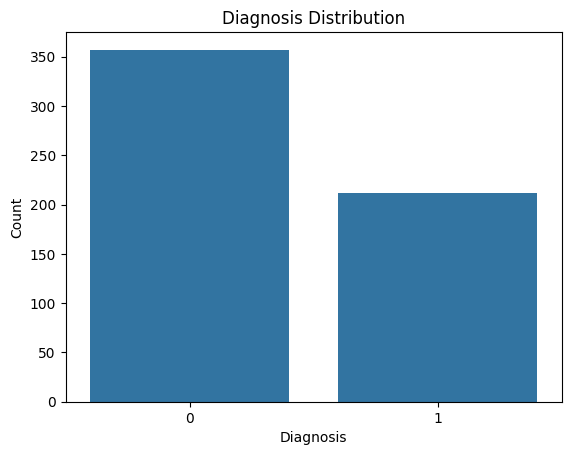

In [ ]:
sns.countplot(data=df, x="diagnosis")
plt.title("Diagnosis Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

Convert Diagnosis to Numeric

In [ ]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})

In [ ]:
df = df.drop("id", axis=1)

Separate Features and Target

In [ ]:
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

Separating traiing from testing values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Scaling the Features

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training Model using Linear Regression

In [ ]:
log_model = LogisticRegression(max_iter=10000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
y_pred_log = log_model.predict(X_test_scaled)

Logistic Regression Evaluation

In [ ]:
print(classification_report(y_test, y_pred_log, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



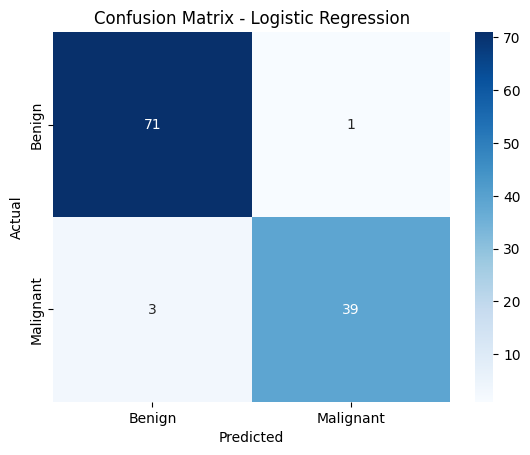

In [ ]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

Training multiple models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Support Vector Machine": SVC()
}

In [ ]:
results = []

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

Sort by Recall

In [ ]:
results_df.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220
4,Support Vector Machine,0.973684,1.000000,0.928571,0.962963
3,Random Forest,0.973684,1.000000,0.928571,0.962963
2,Decision Tree,0.929825,0.904762,0.904762,0.904762
1,K-Nearest Neighbors,0.956140,0.974359,0.904762,0.938272


Model Performance Chart

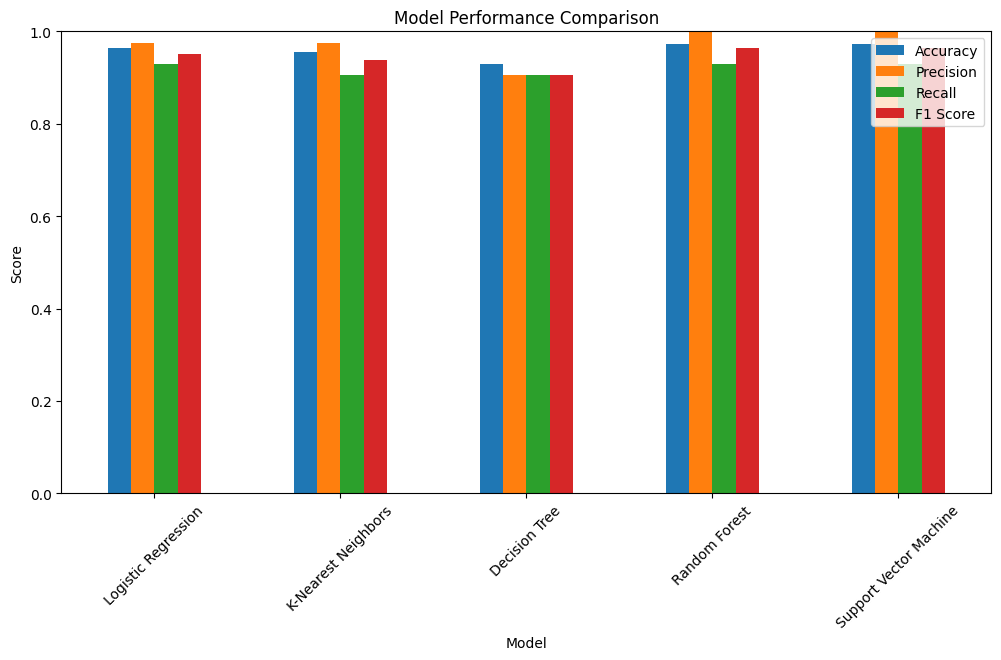

In [ ]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

## Final Model Selection

Based on the model comparison results, the Support Vector Machine and Random Forest models achieved the highest overall performance, both reaching an accuracy of 97.37%, precision of 100%, recall of 92.86%, and F1 score of 96.30%.

For this project, the Support Vector Machine model was selected as the final model because it performed strongly across all evaluation metrics and is well-suited for classification tasks using scaled numerical features. However, since this is a healthcare-related classification problem, recall remains especially important because false negatives may represent malignant tumors incorrectly classified as benign.

Train Vector Machine Model

In [ ]:
final_model = SVC()

final_model.fit(X_train_scaled, y_train)

y_pred_final = final_model.predict(X_test_scaled)

Evaluate Model

In [ ]:
print(classification_report(y_test, y_pred_final, target_names=["Benign", "Malignant"]))

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



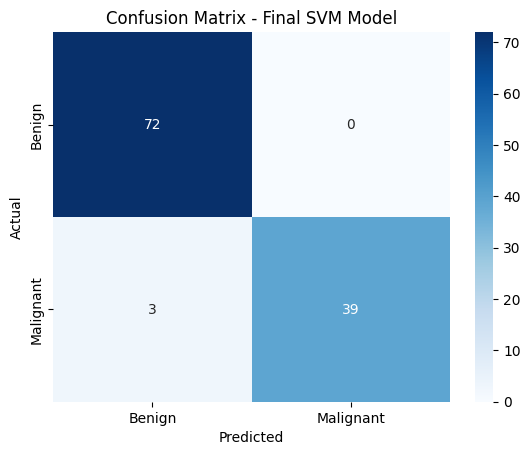

In [ ]:
final_cm = confusion_matrix(y_test, y_pred_final)

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final SVM Model")
plt.show()

In [ ]:
import joblib

joblib.dump(final_model, "breast_cancer_svm_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

## Conclusion

This project built and compared multiple machine learning classification models to predict whether a breast tumor is benign or malignant using the Wisconsin Diagnostic Breast Cancer dataset. The models were trained using numerical features extracted from digitized images of breast mass samples.

Among the tested models, Support Vector Machine and Random Forest achieved the best performance, with 97.37% accuracy and an F1 score of 96.30%. The Support Vector Machine model was selected as the final model because of its strong overall performance on the scaled feature set.

The results show that machine learning can be useful for identifying patterns in medical datasets and supporting early cancer detection. However, because healthcare decisions involve high risk, models like this should be used only as supportive tools alongside expert medical judgment.

## Limitations and Ethical Considerations

Although the model achieved high performance, it has several limitations. The dataset is relatively small, with only 569 samples, and may not represent all patient populations or real-world clinical conditions. The model was also trained only on numerical features extracted from digitized images, not on full medical histories, imaging records, or physician assessments.

In medical applications, false negatives are especially concerning because they occur when a malignant tumor is incorrectly classified as benign. Because of this, machine learning models for healthcare should be carefully validated using larger and more diverse datasets before being used in real clinical settings.

This project is intended for educational and exploratory purposes only. The model should not be used as a standalone diagnostic tool.